In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_alcove_draw_annotated.py
(Annotated, heavily commented version)
"""
from __future__ import annotations
import math
from collections import defaultdict
from typing import Dict, List, Tuple, Iterable
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def enumerate_partitions(Lmax: int) -> Iterable[Tuple[int,int,int]]:
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)

def beta_numbers(lam: Tuple[int,int,int], r: int = 3) -> List[int]:
    l1, l2, l3 = lam
    return [l1 + (r-1), l2 + (r-2), l3 + (r-3)]

def e_weight_of_partition(lam: Tuple[int,int,int], e: int, r: int = 3) -> int:
    betas = beta_numbers(lam, r=r)
    per_runner: Dict[int, List[int]] = {}
    for b in betas:
        residue = b % e
        q = b // e
        per_runner.setdefault(residue, []).append(q)
    w = 0
    for qs in per_runner.values():
        qs_sorted = sorted(qs)
        for j, q in enumerate(qs_sorted):
            w += (q - j)
    return w

def mu_composition(lam: Tuple[int,int,int], e: int, r: int = 3) -> Tuple[int, ...]:
    betas = beta_numbers(lam, r=r)
    counts: Dict[int, int] = {}
    for b in betas:
        residue = b % e
        counts[residue] = counts.get(residue, 0) + 1
    runners_sorted = sorted(counts.keys())
    return tuple(counts[r] for r in runners_sorted)

def omega_coords_lambda_plus_rho(lam: Tuple[int,int,int]) -> Tuple[int,int]:
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)

SQRT3 = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

def to_alcove(points_fw: Iterable[Tuple[int,int]]):
    Xs, Ys = [], []
    for (w1, w2) in points_fw:
        Xs.append(w1 + 0.5*w2)
        Ys.append(SQRT3_2*w2)
    return Xs, Ys

def extents_for_w(data_by_w, w: int):
    allX, allY = [], []
    for pts in data_by_w[w].values():
        Xs, Ys = to_alcove(pts)
        allX.extend(Xs); allY.extend(Ys)
    if not allX:
        return (0.0, 1.0, 0.0, 1.0)
    xmin, xmax = min(allX), max(allX)
    ymin, ymax = min(allY), max(allY)
    mx = max(2.0, 0.12*(xmax - xmin + 1))
    my = max(2.0, 0.12*(ymax - ymin + 1))
    xmin = max(0.0, xmin - mx); xmax = xmax + mx
    ymin = max(0.0, ymin - my); ymax = ymax + my
    return (xmin, xmax, ymin, ymax)

def draw_grid_with_bold_multiples(ax, xmin, xmax, ymin, ymax, e_val, alpha=0.35, lw=0.8, lw_bold=2.2):
    # Family w2 = n (horizontals): y = (√3/2) n
    n2_max = int((2.0/SQRT3)*(ymax + 1)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2*n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y/SQRT3)
        is_bold = (n % e_val == 0 and n != 0)
        ax.plot([x0, xmax], [y, y], color='0.7', alpha=alpha,
                linewidth=(lw_bold if is_bold else lw))
    # Family w1 = n (parallel to ω2)
    n1_min = max(0, int(math.floor(xmin)) - 2)
    n1_max = int(math.ceil(xmax)) + 2
    t_cap = int((2.0/SQRT3)*(ymax + 1)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5*t_cap, SQRT3_2*t_cap)
        is_bold = (n % e_val == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1], color='0.7', alpha=alpha,
                linewidth=(lw_bold if is_bold else lw))
    # Family w1 + w2 = m (diagonals with slope -√3)
    m_min = max(0, int(math.floor(xmin))) - 2
    m_max = int(math.ceil(xmax + (2.0/SQRT3)*(ymax + 1))) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1)*2.0/SQRT3), m)
        x1 = m - 0.5*t_cap
        y1 = SQRT3_2*t_cap
        is_bold = (m % e_val == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1], color='0.7', alpha=alpha,
                linewidth=(lw_bold if is_bold else lw))

def draw_wedge_outline(ax, xmin, xmax, ymin, ymax, lw=3.0):
    ax.plot([xmin, xmax], [0, 0], color='0.2', linewidth=lw)
    x0 = max(xmin, 0.0); x1 = min(xmax, ymax/SQRT3)
    ax.plot([x0, x1], [SQRT3*x0, SQRT3*x1], color='0.2', linewidth=lw)

MU_COLOURS = {(3,): 'red', (2,1): 'orange', (1,2): 'blue', (1,1,1): 'green'}
MUS_ORDER = [(3,), (2,1), (1,2), (1,1,1)]

def size_for_w(w: int, s_min: float = 10.0, s_max: float = 28.0) -> float:
    w = max(0, min(10, w))
    return s_max - (s_max - s_min) * (w / 10.0)

def plot_one(fig, ax, e_val, data_by_w, w, variable_dot_size=True, alpha_points=0.9):
    xmin, xmax, ymin, ymax = extents_for_w(data_by_w, w)
    draw_grid_with_bold_multiples(ax, xmin, xmax, ymin, ymax, e_val, alpha=0.35, lw=0.8, lw_bold=2.2)
    s = size_for_w(w) if variable_dot_size else 24.0
    for mu in MUS_ORDER:
        pts = data_by_w[w].get(mu, [])
        if pts:
            Xs, Ys = to_alcove(pts)
            ax.scatter(Xs, Ys, s=s, marker='o', alpha=alpha_points,
                       label=str(mu), color=MU_COLOURS[mu])
    draw_wedge_outline(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(xmin, xmax); ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    fig.text(0.02, 0.98, f"(r,e,w)=(3,{e_val},{w})",
             ha='left', va='top', fontsize=16, weight='bold')
    ax.legend(title='μ pattern', fontsize='small', markerscale=1.2, frameon=False, loc='upper right')

def build_dataset(e: int, w_max: int, Lmax: int = 130):
    data_by_w = {w: defaultdict(list) for w in range(w_max + 1)}
    for lam in enumerate_partitions(Lmax):
        w = e_weight_of_partition(lam, e=e, r=3)
        if w <= w_max:
            mu = mu_composition(lam, e=e, r=3)
            w1, w2 = omega_coords_lambda_plus_rho(lam)
            data_by_w[w][mu].append((w1, w2))
    return data_by_w

def generate_sl3_alcove_figures(e_val, w_min=0, w_max=10, prefix_base="sl3_eXX_alcove", Lmax=130, variable_dot_size=True, save_pdf=True):
    data_by_w = build_dataset(e=e_val, w_max=w_max, Lmax=Lmax)
    pngs = []
    pdf_path = f"{prefix_base}_boldgrid_all_w{w_min}-{w_max}.pdf"
    pdf = PdfPages(pdf_path) if save_pdf else None
    try:
        for w in range(w_min, w_max + 1):
            fig, ax = plt.subplots(figsize=(9.5, 7.5))
            plot_one(fig, ax, e_val, data_by_w, w, variable_dot_size=variable_dot_size)
            png_path = f"{prefix_base}_boldgrid_w{w}.png"
            fig.savefig(png_path, dpi=220, bbox_inches='tight')
            if pdf is not None:
                pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            pngs.append(png_path)
    finally:
        if pdf is not None:
            pdf.close()
    return pngs, pdf_path

if __name__ == "__main__":
    print("Annotated module loaded. Example:")
    print("  from sl3_alcove_draw_annotated import generate_sl3_alcove_figures")
    print("  generate_sl3_alcove_figures(3, 0, 10, prefix_base='sl3_e10_alcove')")

     
    
generate_sl3_alcove_figures(3, 0, 10, prefix_base="sl3_e10_alcove")


Annotated module loaded. Example:
  from sl3_alcove_draw_annotated import generate_sl3_alcove_figures
  generate_sl3_alcove_figures(3, 0, 10, prefix_base='sl3_e10_alcove')


(['sl3_e10_alcove_boldgrid_w0.png',
  'sl3_e10_alcove_boldgrid_w1.png',
  'sl3_e10_alcove_boldgrid_w2.png',
  'sl3_e10_alcove_boldgrid_w3.png',
  'sl3_e10_alcove_boldgrid_w4.png',
  'sl3_e10_alcove_boldgrid_w5.png',
  'sl3_e10_alcove_boldgrid_w6.png',
  'sl3_e10_alcove_boldgrid_w7.png',
  'sl3_e10_alcove_boldgrid_w8.png',
  'sl3_e10_alcove_boldgrid_w9.png',
  'sl3_e10_alcove_boldgrid_w10.png'],
 'sl3_e10_alcove_boldgrid_all_w0-10.pdf')

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Annotated SL(3) / A2 alcove plotting utilities.

What this does
--------------
For r=3 (type A2):
1) Enumerate all partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) up to a safe bound Lmax.
2) Compute the e-weight of each λ using the r-bead e-abacus via β-numbers.
3) Map λ+ρ to fundamental-weight coordinates ω(λ+ρ) = (ω1, ω2) with
   ω1 = λ1 - λ2 + 1,  ω2 = λ2 - λ3 + 1.
4) Plot these ω-points inside the dominant chamber wedge, on a triangular (affine A2) mesh.
5) Colour points by their μ-pattern (runner usage of β’s): (3), (2,1), (1,2), (1,1,1).
6) Bold all mesh lines whose integer index is a positive multiple of e (i.e. e, 2e, 3e, …).
7) Auto-zoom per w, label “(r,e,w)=(3,*,*)” outside the wedge, and shrink dot size as w grows.

Dependencies: matplotlib (only).
"""

from __future__ import annotations
import math
from collections import defaultdict
from typing import Dict, List, Tuple, Iterable

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


# =============================================================================
# Part I. Partitions (≤3 parts), β-numbers, e-weight, μ-pattern, ω-coordinates
# =============================================================================

def enumerate_partitions(Lmax: int) -> Iterable[Tuple[int, int, int]]:
    """
    Yield all partitions λ = (λ1, λ2, λ3) with λ1 ≥ λ2 ≥ λ3 ≥ 0 and λ1 ≤ Lmax.

    We use a finite Lmax because for fixed e and small w, only finitely many λ
    have e-weight ≤ w. A value like Lmax≈120–160 is typically plenty for w≤10.
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int], r: int = 3) -> List[int]:
    """
    r-bead β-numbers: β_i(λ) = λ_i + (r - i), i=1..r.
    For r=3: β(λ) = [λ1+2, λ2+1, λ3+0].
    """
    l1, l2, l3 = lam
    return [l1 + (r-1), l2 + (r-2), l3 + (r-3)]


def e_weight_of_partition(lam: Tuple[int, int, int], e: int, r: int = 3) -> int:
    """
    Compute the e-weight w(λ) using the r-bead e-abacus.

    Put each β on a runner by writing β = e*q + residue (0≤residue<e).
    On each runner, pack the beads 'upwards' so their q’s become 0,1,2,… .
    The number of upward moves is:
        if the sorted q’s are q_0 ≤ q_1 ≤ … ≤ q_{k-1},  then  Σ_j (q_j - j).
    """
    betas = beta_numbers(lam, r=r)
    per_runner: Dict[int, List[int]] = {}
    for b in betas:
        residue = b % e
        q = b // e
        per_runner.setdefault(residue, []).append(q)

    w = 0
    for qs in per_runner.values():
        qs.sort()
        for j, q in enumerate(qs):
            w += (q - j)
    return w


def mu_composition(lam: Tuple[int, int, int], e: int, r: int = 3) -> Tuple[int, ...]:
    """
    μ-pattern (runner usage) for λ: for each residue (runner) hit by β(λ),
    count how many of the r=3 beads lie on it; order by residue index.
    For r=3 this is one of: (3), (2,1), (1,2), (1,1,1).
    """
    betas = beta_numbers(lam, r=r)
    counts: Dict[int, int] = {}
    for b in betas:
        residue = b % e
        counts[residue] = counts.get(residue, 0) + 1
    return tuple(counts[r] for r in sorted(counts))


def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    Fundamental-weight coordinates of λ+ρ for sl3:
        ω1 = λ1 - λ2 + 1,   ω2 = λ2 - λ3 + 1.
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


def build_dataset(e: int, w_max: int, Lmax: int = 130) -> Dict[int, Dict[Tuple[int, ...], List[Tuple[int, int]]]]:
    """
    Enumerate partitions and collect points grouped by e-weight and μ-pattern.

    Returns a nested dict:
        data_by_w[w][μ] = list of (ω1, ω2) points with e-weight(λ)=w and μ(λ)=μ.
    """
    data_by_w: Dict[int, Dict[Tuple[int, ...], List[Tuple[int, int]]]] = {
        w: defaultdict(list) for w in range(w_max + 1)
    }
    for lam in enumerate_partitions(Lmax):
        w = e_weight_of_partition(lam, e=e, r=3)
        if w <= w_max:
            mu = mu_composition(lam, e=e, r=3)
            w1, w2 = omega_coords_lambda_plus_rho(lam)
            data_by_w[w][mu].append((w1, w2))
    return data_by_w


# =============================================================================
# Part II. Geometry in A2: embedding, wedge extents, and the triangular mesh
# =============================================================================

SQRT3 = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0  # = sin(60°)


def to_alcove(points_fw: Iterable[Tuple[int, int]]) -> Tuple[List[float], List[float]]:
    """
    Embed (ω1, ω2) into the usual equilateral-triangle lattice coordinates:
        x = ω1 + 0.5*ω2,   y = (√3/2)*ω2.

    This realizes the three integer line families as:
      • ω2 = n  -> horizontals y = (√3/2) n
      • ω1 = n  -> lines of slope +√3 (parallel to the ω2 boundary)
      • ω1+ω2 = m -> lines of slope -√3
    """
    Xs, Ys = [], []
    for (w1, w2) in points_fw:
        Xs.append(w1 + 0.5*w2)
        Ys.append(SQRT3_2 * w2)
    return Xs, Ys


def extents_for_w(data_by_w, w: int) -> Tuple[float, float, float, float]:
    """
    Auto-zoom: compute [xmin,xmax]×[ymin,ymax] to tightly frame all points for weight w,
    then pad by a small margin; clip minima to y≥0 to stay in the dominant chamber.
    """
    allX, allY = [], []
    for pts in data_by_w[w].values():
        Xs, Ys = to_alcove(pts)
        allX.extend(Xs)
        allY.extend(Ys)

    if not allX:
        return (0.0, 1.0, 0.0, 1.0)

    xmin, xmax = min(allX), max(allX)
    ymin, ymax = min(allY), max(allY)

    # Margins: wide enough to reveal 'turning points' and mesh context.
    mx = max(2.0, 0.12 * (xmax - xmin + 1.0))
    my = max(2.0, 0.12 * (ymax - ymin + 1.0))
    xmin = max(0.0, xmin - mx)
    xmax = xmax + mx
    ymin = max(0.0, ymin - my)
    ymax = ymax + my
    return (xmin, xmax, ymin, ymax)


def draw_grid_with_bold_multiples(
    ax,
    xmin: float,
    xmax: float,
    ymin: float,
    ymax: float,
    e_val: int,
    alpha: float = 0.35,
    lw: float = 0.8,
    lw_bold: float = 2.2,
):
    """
    Draw the three integer line families inside the dominant wedge and
    bold the members whose integer index is a positive multiple of e (e, 2e, 3e, …).

    Families:
      1) ω2 = n        -> horizontals:        y = (√3/2) n
      2) ω1 = n        -> slope +√3 lines (parallel to the ω2 boundary)
      3) ω1 + ω2 = m   -> slope −√3 lines
    """
    # 1) ω2 = n (horizontals)
    n2_max = int((2.0 / SQRT3) * (ymax + 1)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)  # start at the ω2-edge or xmin
        is_bold = (n % e_val == 0 and n != 0)
        ax.plot(
            [x0, xmax],
            [y, y],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if is_bold else lw),
        )

    # 2) ω1 = n (parallel to ω2 boundary)
    n1_min = max(0, int(math.floor(xmin)) - 2)
    n1_max = int(math.ceil(xmax)) + 2
    t_cap = int((2.0 / SQRT3) * (ymax + 1)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5 * t_cap, SQRT3_2 * t_cap)
        is_bold = (n % e_val == 0 and n != 0)
        ax.plot(
            [x0, x1],
            [y0, y1],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if is_bold else lw),
        )

    # 3) ω1 + ω2 = m (slope −√3)
    m_min = max(0, int(math.floor(xmin))) - 2
    m_max = int(math.ceil(xmax + (2.0 / SQRT3) * (ymax + 1))) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1) * 2.0 / SQRT3), m)
        x1 = m - 0.5 * t_cap
        y1 = SQRT3_2 * t_cap
        is_bold = (m % e_val == 0 and m != 0)
        ax.plot(
            [x0, x1],
            [y0, y1],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if is_bold else lw),
        )


def draw_wedge_outline(ax, xmin: float, xmax: float, ymin: float, ymax: float, lw: float = 3.0):
    """
    Dominant chamber wedge boundary:
      • base: y = 0,
      • ω2-edge: y = √3 x  (clipped to current x-range).
    """
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3 * x0, SQRT3 * x1], color="0.2", linewidth=lw)


# =============================================================================
# Part III. Plotting helpers and the main figure generator
# =============================================================================

# μ-colour scheme (fixed):
MU_COLOURS = {
    (3,): "red",
    (2, 1): "orange",
    (1, 2): "blue",
    (1, 1, 1): "green",
}
MUS_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


def size_for_w(w: int, s_min: float = 10.0, s_max: float = 28.0) -> float:
    """
    Marker size schedule: larger for small w, smaller for large w (reduces clutter).
    Linear map with s(0)=s_max and s(10)=s_min.
    """
    w = max(0, min(10, w))
    return s_max - (s_max - s_min) * (w / 10.0)


def plot_one(
    fig,
    ax,
    e_val: int,
    data_by_w,
    w: int,
    variable_dot_size: bool = True,
    alpha_points: float = 0.9,
):
    """
    Draw one frame for a fixed weight w:
      - mesh with bold multiples of e,
      - μ-coloured 'little balls',
      - dominant wedge outline,
      - label (r,e,w) placed outside the wedge (figure margin).
    """
    xmin, xmax, ymin, ymax = extents_for_w(data_by_w, w)

    # 1) Background triangular mesh
    draw_grid_with_bold_multiples(
        ax, xmin, xmax, ymin, ymax, e_val, alpha=0.35, lw=0.8, lw_bold=2.2
    )

    # 2) Scatter the points
    s = size_for_w(w) if variable_dot_size else 24.0
    for mu in MUS_ORDER:
        pts = data_by_w[w].get(mu, [])
        if pts:
            Xs, Ys = to_alcove(pts)
            ax.scatter(Xs, Ys, s=s, marker="o", alpha=alpha_points, color=MU_COLOURS[mu], label=str(mu))

    # 3) Wedge boundary and frame cosmetics
    draw_wedge_outline(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # 4) Label in the figure margin (kept outside the chamber)
    # fig.text(0.02, 0.98, f"(r,e,w)=(3,{e_val},{w})", ha="left", va="top", fontsize=16, weight="bold")

    # 5) Legend (μ-pattern)
    ax.legend(title="μ pattern", fontsize="small", markerscale=1.2, frameon=False, loc="upper left")


def generate_sl3_alcove_figures(
    e_val: int,
    w_min: int = 0,
    w_max: int = 10,
    prefix_base: str = "sl3_eXX_alcove",
    Lmax: int = 130,
    variable_dot_size: bool = True,
    save_pdf: bool = True,
):
    """
    Generate a PNG per w and (optionally) a combined PDF.
    Files are saved into the current working directory (or the directory of prefix_base).

    Filenames:
      {prefix_base}_boldgrid_w{w}.png
      {prefix_base}_boldgrid_all_w{w_min}-{w_max}.pdf
    """
    data_by_w = build_dataset(e=e_val, w_max=w_max, Lmax=Lmax)

    pngs = []
    pdf_path = f"{prefix_base}_boldgrid_all_w{w_min}-{w_max}.pdf"
    pdf = PdfPages(pdf_path) if save_pdf else None

    try:
        for w in range(w_min, w_max + 1):
            fig, ax = plt.subplots(figsize=(9.5, 7.5))
            plot_one(fig, ax, e_val, data_by_w, w, variable_dot_size=variable_dot_size)
            png_path = f"{prefix_base}_boldgrid_w{w}.png"
            fig.savefig(png_path, dpi=220, bbox_inches="tight")
            if pdf is not None:
                pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
            pngs.append(png_path)
    finally:
        if pdf is not None:
            pdf.close()

    return pngs, pdf_path


# Example usage (uncomment to generate directly when running this file):
# if __name__ == "__main__":
    # (r,e)=(3,10), w=0..10 into the current folder:
generate_sl3_alcove_figures(4, 0, 10, prefix_base="sl3_e10_alcove")
    # (r,e)=(3,8), w=0..10:
# generate_sl3_alcove_figures(3, 10, 0, prefix_base="sl3_e3_alcove")
# generate_sl3_alcove_figures(3, 0, 10, prefix_base="sl3_e10_alcove")


Matplotlib is building the font cache; this may take a moment.


(['sl3_e10_alcove_boldgrid_w0.png',
  'sl3_e10_alcove_boldgrid_w1.png',
  'sl3_e10_alcove_boldgrid_w2.png',
  'sl3_e10_alcove_boldgrid_w3.png',
  'sl3_e10_alcove_boldgrid_w4.png',
  'sl3_e10_alcove_boldgrid_w5.png',
  'sl3_e10_alcove_boldgrid_w6.png',
  'sl3_e10_alcove_boldgrid_w7.png',
  'sl3_e10_alcove_boldgrid_w8.png',
  'sl3_e10_alcove_boldgrid_w9.png',
  'sl3_e10_alcove_boldgrid_w10.png'],
 'sl3_e10_alcove_boldgrid_all_w0-10.pdf')

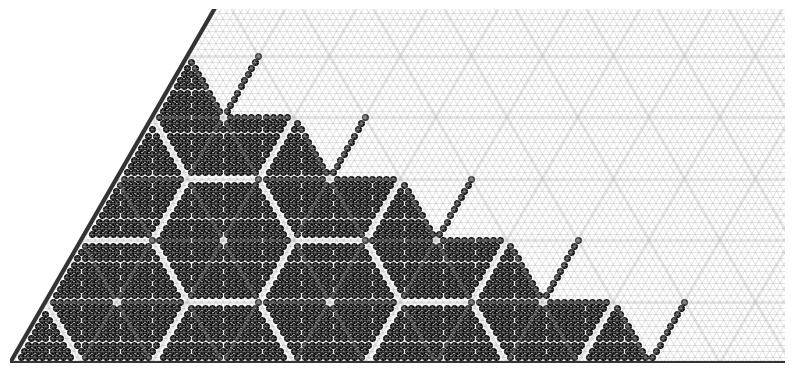

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_mu_indexed_plot.py

Features
--------
- r = 3, abacus-based enumeration at fixed (e, w)
- Safe Lmax(e,w); correct e-weight via abacus
- Build (μ, Λ) buckets and dominant weights (ω1, ω2)
- sl3 equilateral plot with A2 mesh; multiples of e bold
- Dominant chamber wedge outline
- Points colored by μ pattern:
    (3)     -> red
    (2,1)   -> orange
    (1,2)   -> blue
    (1,1,1) -> green
- By default, μ=(1,1,1) dots are SUPPRESSED (as requested earlier), but:
  * You can turn them back on via include_mu111_points=True
  * Their labels are still drawn when labeling is enabled
- Labels:
    * label_mu=None      -> label all simplices (labels in μ-colour or monochrome)
    * label_mu=(3,), (2,1), (1,2), (1,1,1) -> only that μ is labelled, in bold black (with white halo if available)
    * For μ=(1,1,1), labels shown as weak composition (a,b,c) with zeros (compact)
- Toggles:
    * monochrome=True    -> ignore μ colours (use single point_color)
    * point_color="0.15" -> default dark grey for monochrome dots
    * show_labels=False  -> hide all labels
    * show_legend=False  -> hide legend (auto-hidden if monochrome=True)
    * include_mu111_points=False -> draw μ=(1,1,1) dots when True

Run this file directly to see a few example outputs written alongside the script.
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Optional

import matplotlib.pyplot as plt
from matplotlib.path import Path

# Optional: better label readability (white halo)
try:
    import matplotlib.patheffects as patheffects
    _HAS_PE = True
except Exception:
    patheffects = None
    _HAS_PE = False


# -----------------------------
# Palette & geometry constants
# -----------------------------

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

MU_COLOURS: Dict[Tuple[int, ...], str] = {
    (3,):        "red",
    (2, 1):      "orange",
    (1, 2):      "blue",
    (1, 1, 1):   "green",
}
MU_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


# -----------------------------
# r=3 partitions & abacus
# -----------------------------

def enumerate_partitions(Lmax: int):
    """Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) with 0 ≤ λ1 ≤ Lmax."""
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)

def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """r=3 β-numbers: β1=λ1+2, β2=λ2+1, β3=λ3."""
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]

def abacus_from_lam(lam: Tuple[int, int, int], e: int) -> Dict[int, List[int]]:
    """
    Build e-runner abacus from λ:
      β = r + e q  -> bead at (runner r, level q).
    Returns dict r -> sorted list of q.
    """
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per

def lam_from_betas(betas: List[int]) -> Tuple[int, int, int]:
    """Invert β ↦ λ for r=3."""
    bs = sorted(betas, reverse=True)
    assert len(bs) == 3
    l1 = bs[0] - 2
    l2 = bs[1] - 1
    l3 = bs[2]
    assert l1 >= l2 >= l3 >= 0
    return (l1, l2, l3)

def lam_from_abacus(per: Dict[int, List[int]], e: int) -> Tuple[int, int, int]:
    """Collect β = r + e q from abacus and convert to λ."""
    betas: List[int] = []
    for r, qs in per.items():
        for q in qs:
            betas.append(r + e*q)
    return lam_from_betas(betas)

def e_weight(lam: Tuple[int, int, int], e: int) -> int:
    """
    e-weight via abacus:
      For each runner: q_0 ≤ ... ≤ q_{μ-1}, contrib = sum_j (q_j - j),
      then sum over runners.
    """
    per = abacus_from_lam(lam, e)
    w = 0
    for qs in per.values():
        for j, q in enumerate(sorted(qs)):
            w += (q - j)
    return w

def mu_composition(lam: Tuple[int, int, int], e: int) -> Tuple[int, ...]:
    """
    μ-composition from residues of β:
      - Count beads on each runner,
      - Sort runners,
      - Return their counts as a composition of 3.
    """
    counts: Dict[int, int] = defaultdict(int)
    for b in beta_numbers(lam):
        counts[b % e] += 1
    runners = sorted(counts.keys())
    return tuple(counts[r] for r in runners)

def multipartition_index(lam: Tuple[int, int, int], e: int):
    """
    From abacus of λ, extract (μ, Λ):

      For each runner r used:
        μ_i = #beads,
        q_0 ≤ ... ≤ q_{μ_i-1},
        d_k = q_k - k ≥ 0,
        positive d_k in decreasing order form λ^(i).

    Returns
    -------
    μ : tuple of ints           (composition of 3)
    Λ : tuple of partitions     (each a tuple of ints in decreasing order)
    """
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)
    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per[r])
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))
    return mu, tuple(multipart)

def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    Dominant weight (λ+ρ) in (ω1,ω2):
        ω1 = λ1 - λ2 + 1,
        ω2 = λ2 - λ3 + 1.
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -----------------------------
# Safe Lmax(e,w)
# -----------------------------

def safe_Lmax(e: int, w: int) -> int:
    """
    Safe bound for λ1 with r=3, given e-weight w.
    Sketch:
      q_j - j ≥ 0, sum(q_j - j) = w => q_j ≤ j + w.
      max q_j ≤ 2 + w.
      β_max < e(w+3) => λ1 = β_max - 2 < e(w+3).
    """
    return e * (w + 3)


# -----------------------------
# Build (μ,Λ) -> weights
# -----------------------------

def build_mu_Lambda_buckets(e: int, w: int):
    """
    Enumerate λ with e-weight(λ)=w up to Lmax(e,w),
    and group dominant weights by (μ, Λ).
    Returns dict: (μ, Λ) -> set of (ω1,ω2)
    """
    Lmax = safe_Lmax(e, w)
    buckets: Dict[
        Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]],
        Set[Tuple[int, int]],
    ] = defaultdict(set)
    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue
        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        buckets[(mu, multipart)].add(omega)
    return buckets


# -----------------------------
# Equilateral sl3 geometry
# -----------------------------

def to_equilateral(points_fw: List[Tuple[int, int]]):
    """(ω1,ω2) -> (x,y) with x=ω1+0.5ω2, y=(√3/2)ω2."""
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5*w2)
        Y.append(SQRT3_2 * w2)
    return X, Y

def extents_from_buckets(buckets) -> Tuple[float, float, float, float]:
    pts = [p for pts in buckets.values() for p in pts]
    if not pts:
        return (0.0, 1.0, 0.0, 1.0)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15*(xmax - xmin + 1.0))
    my = max(1.5, 0.15*(ymax - ymin + 1.0))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my

def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e: int,
                          alpha: float = 0.35, lw: float = 0.7, lw_bold: float = 2.0):
    # ω2 = n
    n2_max = int((2.0/SQRT3)*(ymax + 1.0)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, xmax], [y, y], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))
    # ω1 = n
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap  = int((2.0/SQRT3)*(ymax + 1.0)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5*t_cap, SQRT3_2*t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))
    # ω1 + ω2 = m
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0/SQRT3)*(ymax + 1.0)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0)*2.0/SQRT3), m)
        x1 = m - 0.5*t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

def wedge_clip_equilateral(xmin, xmax, ymin, ymax):
    """Dominant chamber wedge as a Path (not applied as clip by default)."""
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3*x1),
        (x0, SQRT3*x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    return Path(verts, codes)

def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw: float = 3.0):
    """Draw boundary of dominant wedge: y=0 and y=√3 x."""
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3*x0, SQRT3*x1], color="0.2", linewidth=lw)


# -----------------------------
# Labels
# -----------------------------

def multipartition_label(multipart: Tuple[Tuple[int, ...], ...]) -> str:
    """Compact label for Λ = (λ^(1),...,λ^(j)): e.g. '(2,1)·(1)·∅'."""
    pieces: List[str] = []
    for lam in multipart:
        if not lam:
            pieces.append("∅")
        else:
            pieces.append("(" + ",".join(str(x) for x in lam) + ")")
    return "·".join(pieces)

def multipartition_label_compact(mu: Tuple[int, ...],
                                 multipart: Tuple[Tuple[int, ...], ...]) -> str:
    """
    For μ=(1,1,1): show weak composition (a,b,c) with zeros (first part or 0).
    For other μ: fall back to multipartition_label.
    """
    if mu == (1, 1, 1) and len(multipart) == 3:
        def first_or_zero(part: Tuple[int, ...]) -> int:
            return part[0] if part else 0
        a = first_or_zero(multipart[0])
        b = first_or_zero(multipart[1])
        c = first_or_zero(multipart[2])
        return f"({a},{b},{c})"
    else:
        return multipartition_label(multipart)


# -----------------------------
# Main plotting function
# -----------------------------

def plot_sl3_indexed_simplices(
    e: int,
    w: int,
    label_mu: Optional[Tuple[int, ...]] = None,
    label_fontsize: int = 7,
    max_labels: int = 999,
    out_prefix: Optional[str] = None,
    *,
    # toggles:
    monochrome: bool = False,          # ignore μ colours; use one colour for all dots
    point_color: str = "0.15",         # used when monochrome=True
    show_labels: bool = True,          # hide all labels if False
    show_legend: bool = True,          # hide legend if False (also auto-hide when monochrome=True)
    include_mu111_points: bool = False,  # draw μ=(1,1,1) dots if True
):
    """
    Draw the sl3 alcove for (r,e,w)=(3,e,w).

    - Dots: coloured by μ unless monochrome=True.
    - μ=(1,1,1) dots are SUPPRESSED by default; enable via include_mu111_points=True.
    - Labels:
        * label_mu=None -> label all (μ≠(1,1,1): multipartition label; μ=(1,1,1): (a,b,c))
        * label_mu in {(3,), (2,1), (1,2), (1,1,1)} -> only that μ, bold black (+halo if available)
        * show_labels=False -> no labels at all
    - Legend suppressed if monochrome=True or show_legend=False.
    """
    buckets = build_mu_Lambda_buckets(e, w)

    all_points = [p for pts in buckets.values() for p in pts]
    if not all_points:
        raise RuntimeError(f"No points for (e,w)=({e},{w}).")

    xmin, xmax, ymin, ymax = extents_from_buckets(buckets)
    fig, ax = plt.subplots(figsize=(10, 8))

    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    _ = wedge_clip_equilateral(xmin, xmax, ymin, ymax)

    # Dot size schedule (shrink mildly with big w)
    # sz = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    # sz = max(18, min(32, sz))
    sz=17

    labels_drawn = 0

    for (mu, multipart), pts_fw in sorted(buckets.items()):
        if not pts_fw:
            continue

        mu_color = MU_COLOURS.get(mu, "black")
        dot_color = point_color if monochrome else mu_color
        X, Y = to_equilateral(sorted(pts_fw))

        # Draw dots:
        if include_mu111_points or mu != (1, 1, 1):
            ax.scatter(X, Y, s=sz, marker="o", color=dot_color, alpha=0.9)

        if not show_labels:
            continue

        # Decide labeling policy
        if label_mu is None:
            do_label = True
            txt_color = ("black" if monochrome else mu_color)
            bold = False
            halo = False
        else:
            if mu == label_mu:
                do_label = True
                txt_color = "black"
                bold = True
                halo = True
            else:
                do_label = False
                txt_color = mu_color
                bold = False
                halo = False

        if do_label and labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            text = multipartition_label_compact(mu, multipart)
            t = ax.text(
                bx, by, text,
                fontsize=label_fontsize,
                color=txt_color,
                ha="center", va="center",
                fontweight=("bold" if bold else "normal"),
            )
            if halo and _HAS_PE:
                t.set_path_effects([
                    patheffects.Stroke(linewidth=1.2, foreground="white"),
                    patheffects.Normal(),
                ])
            labels_drawn += 1

    # Wedge outline & cosmetics
    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # (r,e,w) label outside chamber (upper-left of figure)
    # fig.text(0.02, 0.98, f"(r,e,w)=(3,{e},{w})",
    #          ha="left", va="top", fontsize=14, weight="bold")

    # Legend (skip when monochrome or user-disabled)
    if show_legend and (not monochrome):
        from matplotlib.lines import Line2D
        legend_elements: List[Line2D] = []
        for mu_key in MU_ORDER:
            if any(key_mu == mu_key for (key_mu, _Λ) in buckets.keys()):
                legend_elements.append(
                    Line2D([0], [0], marker="o", linestyle="",
                           markersize=6, color=MU_COLOURS[mu_key],
                           label=f"μ={mu_key}")
                )
        if legend_elements:
            ax.legend(handles=legend_elements, title="μ-pattern",
                      loc="upper left", frameon=False, fontsize="small")

    # Save if requested
    if out_prefix:
        fig.savefig(f"{out_prefix}.png", dpi=240, bbox_inches="tight")
        # fig.savefig(f"{out_prefix}.pdf", dpi=240, bbox_inches="tight")

    return fig, ax, buckets


# -----------------------------
# Example tests
# -----------------------------
# Example: e=10, w=6 — ALL simplices, black dots, no labels/legend
e, w = 10, 8
fig, ax, buckets = plot_sl3_indexed_simplices(
    e=e, w=w,
    include_mu111_points=True,   # <- include μ=(1,1,1) dots too
    monochrome=True,             # <- ignore μ-colours
    point_color="black",         # <- draw everything in black
    show_labels=False,           # <- dots only
    show_legend=False,           # <- no colour legend
    out_prefix=f"sl3_e{e}_w{w}_all_black"
)


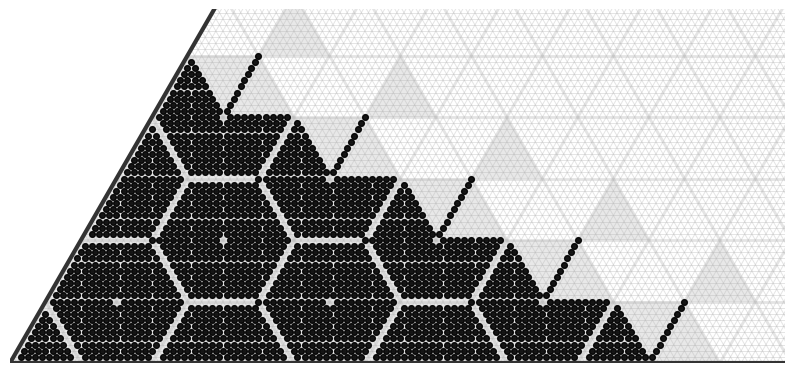

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_stingray_part_closure.py

Updates:
- Implements strict "part closure" logic for shading.
- Every point is assigned to exactly one alcove based on positive/negative sides of walls.
- Integer arithmetic used for precision (no floating point errors).
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Optional

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import Polygon

# Optional: better label readability (white halo)
try:
    import matplotlib.patheffects as patheffects
    _HAS_PE = True
except Exception:
    patheffects = None
    _HAS_PE = False


# -----------------------------
# Palette & geometry constants
# -----------------------------

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

MU_COLOURS: Dict[Tuple[int, ...], str] = {
    (3,):        "red",
    (2, 1):      "orange",
    (1, 2):      "blue",
    (1, 1, 1):   "green",
}
MU_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


# -----------------------------
# r=3 partitions & abacus
# -----------------------------

def enumerate_partitions(Lmax: int):
    """Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) with 0 ≤ λ1 ≤ Lmax."""
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)

def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """r=3 β-numbers: β1=λ1+2, β2=λ2+1, β3=λ3."""
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]

def abacus_from_lam(lam: Tuple[int, int, int], e: int) -> Dict[int, List[int]]:
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per

def e_weight(lam: Tuple[int, int, int], e: int) -> int:
    per = abacus_from_lam(lam, e)
    w = 0
    for qs in per.values():
        for j, q in enumerate(sorted(qs)):
            w += (q - j)
    return w

def multipartition_index(lam: Tuple[int, int, int], e: int):
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)
    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per[r])
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))
    return mu, tuple(multipart)

def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """Dominant weight (λ+ρ) in (ω1,ω2)."""
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -----------------------------
# Safe Lmax & Buckets
# -----------------------------

def safe_Lmax(e: int, w: int) -> int:
    return e * (w + 3)

def build_mu_Lambda_buckets(e: int, w: int):
    Lmax = safe_Lmax(e, w)
    buckets: Dict[
        Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]],
        Set[Tuple[int, int]],
    ] = defaultdict(set)
    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue
        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        buckets[(mu, multipart)].add(omega)
    return buckets


# -----------------------------
# Geometry & Shading Logic
# -----------------------------

def to_equilateral(points_fw: List[Tuple[int, int]]):
    """(ω1,ω2) -> (x,y) with x=ω1+0.5ω2, y=(√3/2)ω2."""
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5*w2)
        Y.append(SQRT3_2 * w2)
    return X, Y

def get_alcove_triangle(k1, k2, alcove_type, e):
    """
    Returns vertices of the alcove in (ω1, ω2) coordinates.
    alcove_type 0 (Up):   Vertices (k1, k2), (k1+1, k2), (k1, k2+1)
    alcove_type 1 (Down): Vertices (k1+1, k2+1), (k1+1, k2), (k1, k2+1)
    """
    if alcove_type == 0:
        pts_norm = [(k1, k2), (k1+1, k2), (k1, k2+1)]
    else:
        pts_norm = [(k1+1, k2+1), (k1+1, k2), (k1, k2+1)]
    
    return tuple(sorted((p[0]*e, p[1]*e) for p in pts_norm))

def get_unique_alcove_for_point(w1: int, w2: int, e: int) -> Tuple[Tuple[int, int], ...]:
    """
    Determines the unique alcove whose "part closure" contains (w1, w2).
    
    Part Closure Rules:
    - Up Triangle T_up: x >= k1, y >= k2, x+y < k_sum
    - Down Triangle T_down: x < k1+1, y < k2+1, x+y >= k_sum
    """
    # 1. Determine the square [k1, k1+1) x [k2, k2+1) containing the point
    #    Since w/e is floor'd, this handles the >= condition for left/bottom walls automatically.
    k1 = w1 // e
    k2 = w2 // e
    
    # 2. Check Diagonal cut
    #    Up Triangle condition: x + y < (k1 + k2 + 1)*e
    #    Down Triangle condition: x + y >= (k1 + k2 + 1)*e
    
    # We use integer arithmetic to avoid float issues
    lhs = w1 + w2
    rhs = e * (k1 + k2 + 1)
    
    if lhs < rhs:
        # Belongs to Up Triangle in square (k1, k2)
        # Verify closure logic: 
        #   x >= k1*e (True by floor) -> Positive side of Left Wall -> Included.
        #   y >= k2*e (True by floor) -> Positive side of Bottom Wall -> Included.
        #   x+y < rhs -> Negative side of Diagonal -> Diagonal Excluded.
        return get_alcove_triangle(k1, k2, 0, e)
    else:
        # Belongs to Down Triangle in square (k1, k2)
        # Verify closure logic:
        #   x+y >= rhs -> Positive side of Diagonal -> Diagonal Included.
        #   x < (k1+1)e is NOT guaranteed by floor if x is integer? 
        #   Actually, the Down Triangle is usually the closure of the open region. 
        #   By floor logic, k1 <= w1/e < k1+1 is true.
        #   The Down Triangle definition excludes the Right/Top walls (x=(k1+1)e).
        #   If w1 was exactly (k1+1)e, then floor(w1/e) would be k1+1, not k1.
        #   So w1 is strictly < (k1+1)e. Thus Right Wall excluded. Correct.
        return get_alcove_triangle(k1, k2, 1, e)

def draw_shaded_alcoves(ax, all_points, e):
    """
    1. Map every point to its unique alcove.
    2. Draw unique alcoves.
    """
    unique_triangles = set()
    for (w1, w2) in all_points:
        tri = get_unique_alcove_for_point(w1, w2, e)
        unique_triangles.add(tri)
        
    for tri_verts in unique_triangles:
        # Convert to equilateral for plotting
        X, Y = to_equilateral(list(tri_verts))
        xy = list(zip(X, Y))
        # Use a light distinct color
        poly = Polygon(xy, closed=True, facecolor="#D3D3D3", edgecolor="none", alpha=0.5, zorder=0)
        ax.add_patch(poly)

def extents_from_buckets(buckets) -> Tuple[float, float, float, float]:
    pts = [p for pts in buckets.values() for p in pts]
    if not pts:
        return (0.0, 1.0, 0.0, 1.0)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15*(xmax - xmin + 1.0))
    my = max(1.5, 0.15*(ymax - ymin + 1.0))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my

def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e: int,
                          alpha: float = 0.35, lw: float = 0.7, lw_bold: float = 2.0):
    # ω2 = n
    n2_max = int((2.0/SQRT3)*(ymax + 1.0)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, xmax], [y, y], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw), zorder=1)
    # ω1 = n
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap  = int((2.0/SQRT3)*(ymax + 1.0)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5*t_cap, SQRT3_2*t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw), zorder=1)
    # ω1 + ω2 = m
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0/SQRT3)*(ymax + 1.0)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0)*2.0/SQRT3), m)
        x1 = m - 0.5*t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1], color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw), zorder=1)

def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw: float = 3.0):
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw, zorder=3)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3*x0, SQRT3*x1], color="0.2", linewidth=lw, zorder=3)

def wedge_clip_equilateral(xmin, xmax, ymin, ymax):
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3*x1),
        (x0, SQRT3*x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    return Path(verts, codes)


# -----------------------------
# Labels
# -----------------------------

def multipartition_label(multipart: Tuple[Tuple[int, ...], ...]) -> str:
    pieces: List[str] = []
    for lam in multipart:
        if not lam:
            pieces.append("∅")
        else:
            pieces.append("(" + ",".join(str(x) for x in lam) + ")")
    return "·".join(pieces)

def multipartition_label_compact(mu: Tuple[int, ...],
                                 multipart: Tuple[Tuple[int, ...], ...]) -> str:
    if mu == (1, 1, 1) and len(multipart) == 3:
        def first_or_zero(part: Tuple[int, ...]) -> int:
            return part[0] if part else 0
        a = first_or_zero(multipart[0])
        b = first_or_zero(multipart[1])
        c = first_or_zero(multipart[2])
        return f"({a},{b},{c})"
    else:
        return multipartition_label(multipart)


# -----------------------------
# Main plotting function
# -----------------------------

def plot_sl3_indexed_simplices(
    e: int,
    w: int,
    label_mu: Optional[Tuple[int, ...]] = None,
    label_fontsize: int = 7,
    max_labels: int = 999,
    out_prefix: Optional[str] = None,
    *,
    monochrome: bool = False,
    point_color: str = "0.15",
    show_labels: bool = True,
    show_legend: bool = True,
    include_mu111_points: bool = False,
    shade_alcoves: bool = True,   # <--- SHADING TOGGLE
):
    buckets = build_mu_Lambda_buckets(e, w)
    all_points = [p for pts in buckets.values() for p in pts]
    if not all_points:
        raise RuntimeError(f"No points for (e,w)=({e},{w}).")

    xmin, xmax, ymin, ymax = extents_from_buckets(buckets)
    fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Shade Alcoves (Background)
    if shade_alcoves:
        draw_shaded_alcoves(ax, all_points, e)

    # 2. Draw Grid
    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    _ = wedge_clip_equilateral(xmin, xmax, ymin, ymax)

    sz = 17
    labels_drawn = 0

    # 3. Draw Points & Labels
    for (mu, multipart), pts_fw in sorted(buckets.items()):
        if not pts_fw:
            continue

        mu_color = MU_COLOURS.get(mu, "black")
        dot_color = point_color if monochrome else mu_color
        X, Y = to_equilateral(sorted(pts_fw))

        if include_mu111_points or mu != (1, 1, 1):
            ax.scatter(X, Y, s=sz, marker="o", color=dot_color, alpha=0.9, zorder=2)

        if not show_labels:
            continue

        if label_mu is None:
            do_label = True
            txt_color = ("black" if monochrome else mu_color)
            bold = False
            halo = False
        else:
            if mu == label_mu:
                do_label = True
                txt_color = "black"
                bold = True
                halo = True
            else:
                do_label = False
                txt_color = mu_color
                bold = False
                halo = False

        if do_label and labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            text = multipartition_label_compact(mu, multipart)
            t = ax.text(
                bx, by, text,
                fontsize=label_fontsize,
                color=txt_color,
                ha="center", va="center",
                fontweight=("bold" if bold else "normal"),
                zorder=4
            )
            if halo and _HAS_PE:
                t.set_path_effects([
                    patheffects.Stroke(linewidth=1.2, foreground="white"),
                    patheffects.Normal(),
                ])
            labels_drawn += 1

    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if show_legend and (not monochrome):
        from matplotlib.lines import Line2D
        legend_elements = []
        for mu_key in MU_ORDER:
            if any(key_mu == mu_key for (key_mu, _Λ) in buckets.keys()):
                legend_elements.append(
                    Line2D([0], [0], marker="o", linestyle="",
                           markersize=6, color=MU_COLOURS[mu_key],
                           label=f"μ={mu_key}")
                )
        if legend_elements:
            ax.legend(handles=legend_elements, title="μ-pattern",
                      loc="upper left", frameon=False, fontsize="small")

    if out_prefix:
        fig.savefig(f"{out_prefix}.png", dpi=240, bbox_inches="tight")

    return fig, ax, buckets

# -----------------------------
# Example tests
# -----------------------------
# Example: e=10, w=8 — Shading enabled (unique alcoves), black dots
e, w = 10, 8
fig, ax, buckets = plot_sl3_indexed_simplices(
    e=e, w=w,
    include_mu111_points=True,
    monochrome=True,
    point_color="black",
    show_labels=False,
    show_legend=False,
    shade_alcoves=True,
    out_prefix=f"sl3_e{e}_w{w}_part_closure"
)
plt.show()